In [3]:
import cv2
import numpy as np
import os
from matplotlib import pyplot as plt

In [4]:
input_folder = "shapes_dataset"

original_folder = "output/original"
contour_folder = "output/contours"
final_folder = "output/final"

os.makedirs(original_folder, exist_ok=True)
os.makedirs(contour_folder, exist_ok=True)
os.makedirs(final_folder, exist_ok=True)

shape1.png
Shape: Square
Area: 5402.00
Perimeter: 294.00
-----------------------------------
shape1.png
Shape: Polygon
Area: 5440.00
Perimeter: 275.76
-----------------------------------
shape1.png
Shape: Triangle
Area: 4187.00
Perimeter: 310.25
-----------------------------------


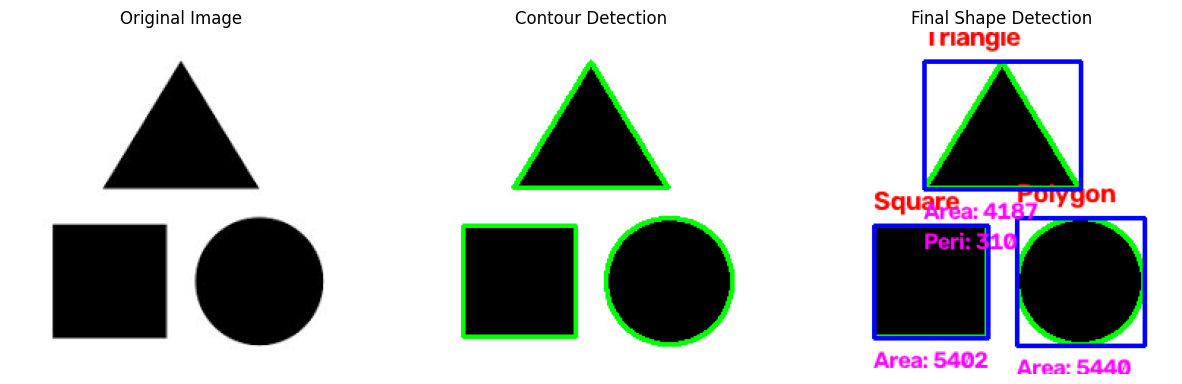

shape10.png
Shape: Rectangle
Area: 76416.00
Perimeter: 1180.00
-----------------------------------


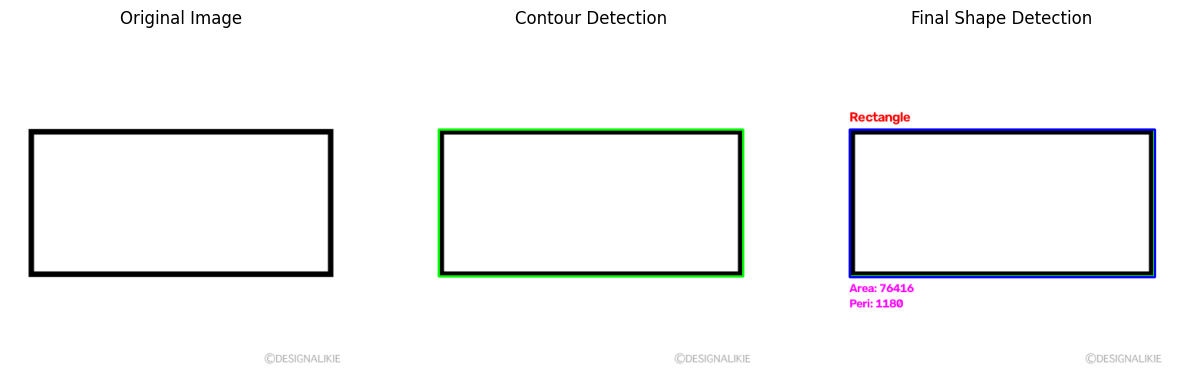

shape2.png
Shape: Hexagon
Area: 40692.00
Perimeter: 785.55
-----------------------------------
shape2.png
Shape: Triangle
Area: 28999.00
Perimeter: 811.35
-----------------------------------
shape2.png
Shape: Square
Area: 47961.00
Perimeter: 876.00
-----------------------------------
shape2.png
Shape: Polygon
Area: 38419.00
Perimeter: 733.70
-----------------------------------


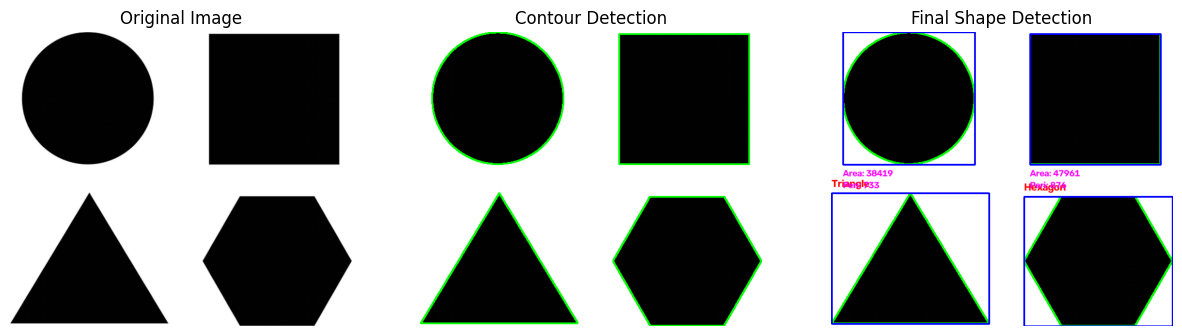

shape3.png
Shape: Polygon
Area: 6870.00
Perimeter: 310.74
-----------------------------------
shape3.png
Shape: Triangle
Area: 6070.00
Perimeter: 355.85
-----------------------------------
shape3.png
Shape: Rectangle
Area: 28235.00
Perimeter: 696.14
-----------------------------------


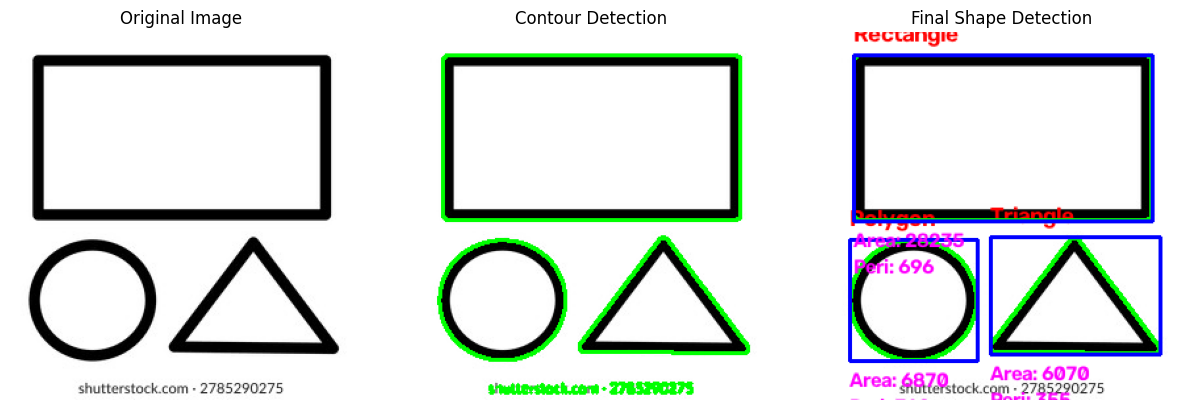

shape4.png
Shape: Triangle
Area: 63234.50
Perimeter: 1233.96
-----------------------------------


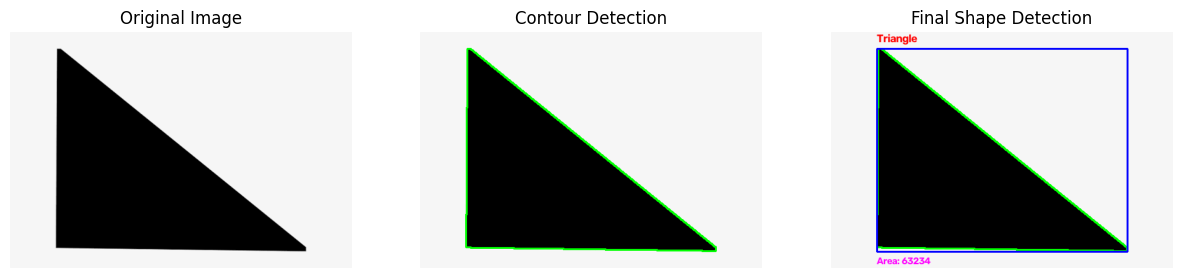

shape5.png
Shape: Triangle
Area: 41115.50
Perimeter: 1099.91
-----------------------------------


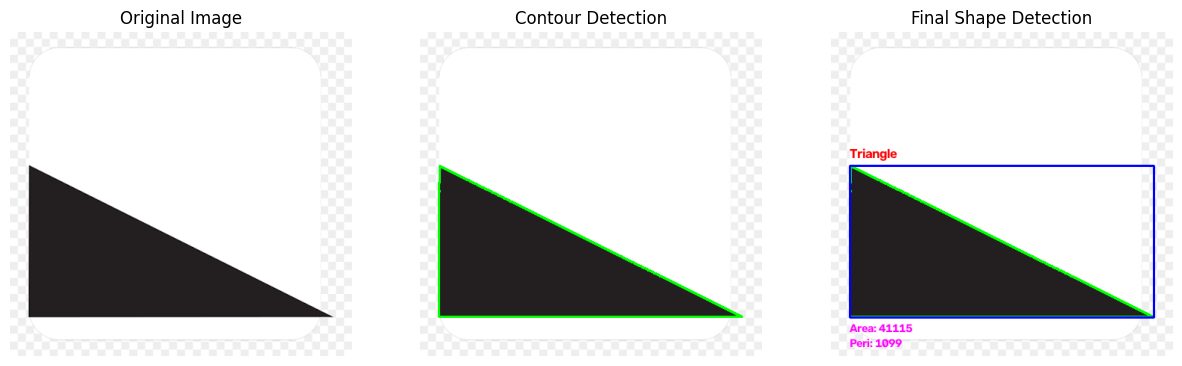

shape6.png
Shape: Rectangle
Area: 44016.00
Perimeter: 860.00
-----------------------------------
shape6.png
Shape: Rectangle
Area: 24192.00
Perimeter: 624.00
-----------------------------------
shape6.png
Shape: Polygon
Area: 18487.00
Perimeter: 508.56
-----------------------------------
shape6.png
Shape: Square
Area: 11015.00
Perimeter: 423.29
-----------------------------------
shape6.png
Shape: Hexagon
Area: 15583.00
Perimeter: 486.62
-----------------------------------
shape6.png
Shape: Rectangle
Area: 44927.50
Perimeter: 911.41
-----------------------------------
shape6.png
Shape: Square
Area: 20592.00
Perimeter: 574.00
-----------------------------------


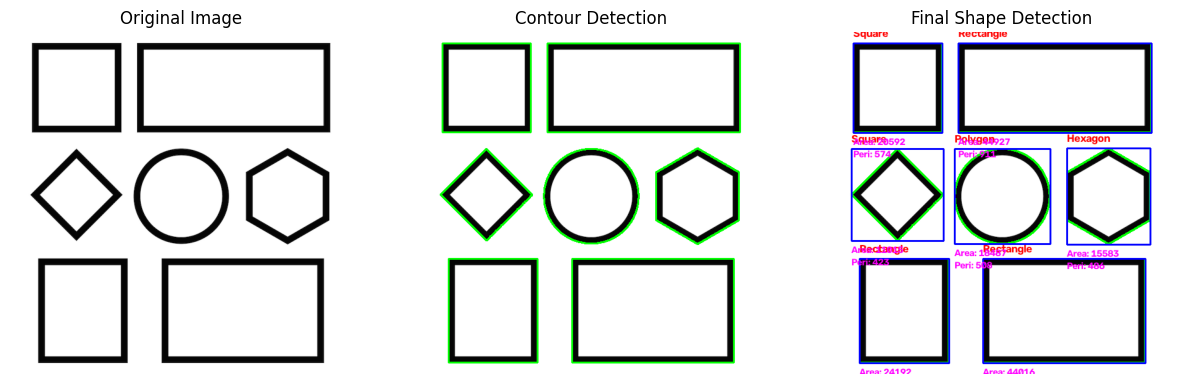

shape7.png
Shape: Circle
Area: 112732.00
Perimeter: 1254.25
-----------------------------------


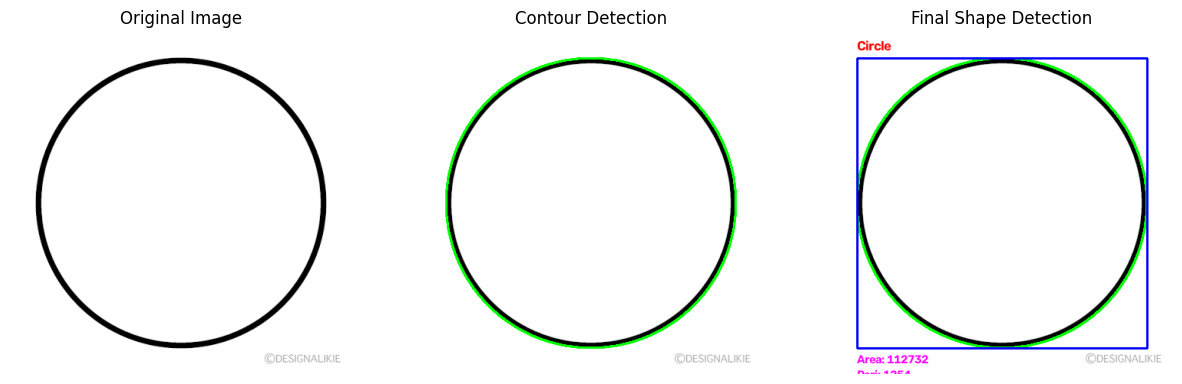

shape8.png
Shape: Square
Area: 116962.00
Perimeter: 1365.66
-----------------------------------


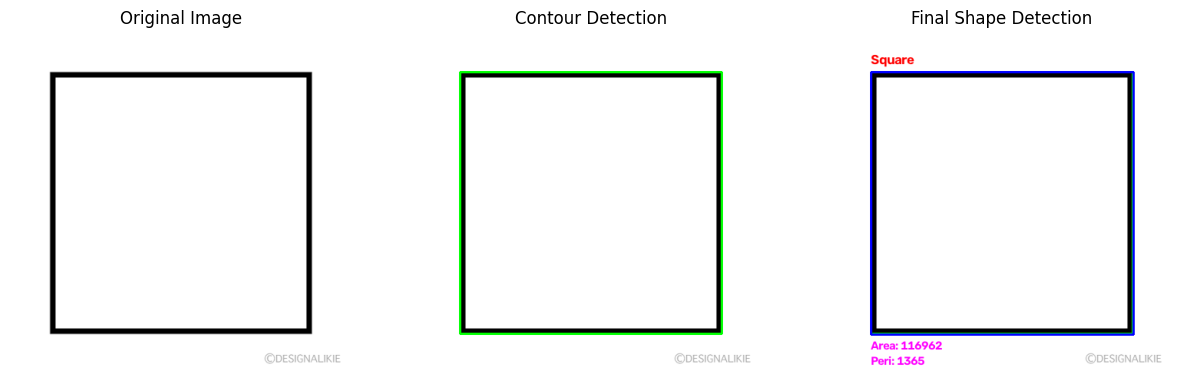

shape9.png
Shape: Triangle
Area: 69839.00
Perimeter: 1264.51
-----------------------------------


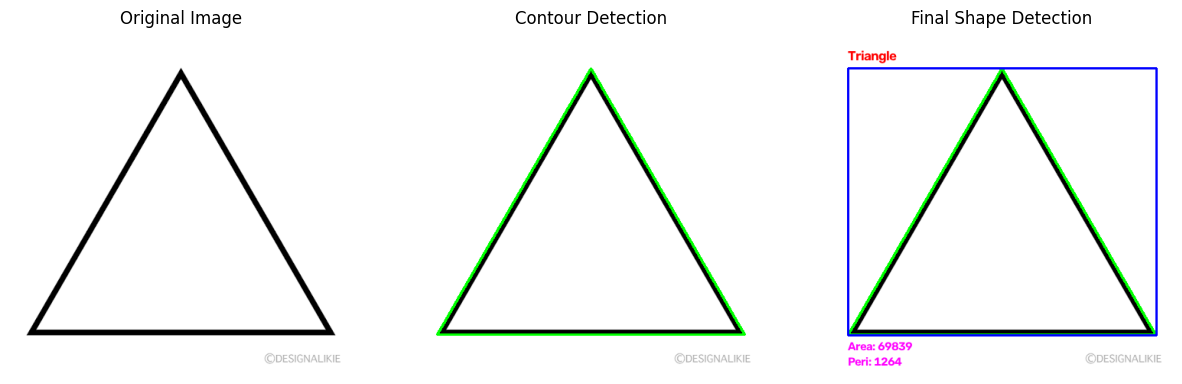

Processing Completed Successfully!


In [5]:
for file in os.listdir(input_folder):
    if not file.lower().endswith((".png", ".jpg", ".jpeg")):
        continue

    image_path = os.path.join(input_folder, file)

    image = cv2.imread(image_path)

    if image is None:
        continue

    # Save Original Image
    cv2.imwrite(os.path.join(original_folder, file), image)

    # Convert to Grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Thresholding
    _, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV)

    # Find Contours
    contours, _ = cv2.findContours(
        thresh,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    # Draw Contours
    contour_image = image.copy()

    cv2.drawContours(
        contour_image,
        contours,
        -1,
        (0, 255, 0),
        2
    )

    # Save Contour Image
    cv2.imwrite(os.path.join(contour_folder, file), contour_image)

    # Final Result Image
    result = image.copy()

    for contour in contours:
        area = cv2.contourArea(contour)

        if area < 100:
            continue

        perimeter = cv2.arcLength(contour, True)

        approx = cv2.approxPolyDP(
            contour,
            0.02 * perimeter,
            True
        )

        corners = len(approx)
        x, y, w, h = cv2.boundingRect(contour)
        cv2.drawContours(result, [contour], -1, (0, 255, 0), 2)
        
        cv2.rectangle(
            result,
            (x, y),
            (x + w, y + h),
            (255, 0, 0),
            2
        )

        # Shape Detection
        if corners == 3:
            shape = "Triangle"
        elif corners == 4:
            ratio = w / float(h)
            if 0.95 <= ratio <= 1.05:
                shape = "Square"
            else:
                shape = "Rectangle"
        elif corners == 5:
            shape = "Pentagon"
        elif corners == 6:
            shape = "Hexagon"
        else:
            circularity = (4 * np.pi * area) / (perimeter * perimeter)
            if circularity > 0.90:
                shape = "Circle"
            else:
                shape = "Polygon"

        # Label Shape
        cv2.putText(
            result,
            shape,
            (x, y - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 0, 255),
            2
        )

        # Display Area
        cv2.putText(
            result,
            f"Area: {int(area)}",
            (x, y + h + 20),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (255, 0, 255),
            2
        )

        # Display Perimeter
        cv2.putText(
            result,
            f"Peri: {int(perimeter)}",
            (x, y + h + 40),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (255, 0, 255),
            2
        )

        print(f"{file}")
        print(f"Shape: {shape}")
        print(f"Area: {area:.2f}")
        print(f"Perimeter: {perimeter:.2f}")
        print("-" * 35)

    # Save Final Image
    cv2.imwrite(os.path.join(final_folder, file), result)

    # Display Images
    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(cv2.cvtColor(contour_image, cv2.COLOR_BGR2RGB))
    plt.title("Contour Detection")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    plt.title("Final Shape Detection")
    plt.axis("off")

    plt.show()

print("Processing Completed Successfully!")